In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# Read fresh data
df_seg = pd.read_csv('/data/df_with_predictions.csv')
print(f"Shape: {df_seg.shape}")
print(f"\nColumns: {df_seg.columns.tolist()}")

# Basic cleaning
ddf_segf = df_seg.drop(columns=['Unnamed: 0'], errors='ignore')
df_seg = df_seg.replace('?', np.nan)

Shape: (196167, 38)

Columns: ['age', 'class_of_worker', 'detailed_industry_recode', 'detailed_occupation_recode', 'education', 'wage_per_hour', 'enroll_in_edu_inst_last_wk', 'marital_stat', 'major_industry_code', 'major_occupation_code', 'race', 'hispanic_origin', 'sex', 'member_of_a_labor_union', 'reason_for_unemployment', 'full_or_part_time_employment_stat', 'capital_gains', 'capital_losses', 'dividends_from_stocks', 'tax_filer_stat', 'region_of_previous_residence', 'state_of_previous_residence', 'detailed_household_and_family_stat', 'detailed_household_summary_in_household', 'live_in_this_house_1_year_ago', 'num_persons_worked_for_employer', 'family_members_under_18', 'country_of_birth_father', 'country_of_birth_mother', 'country_of_birth_self', 'citizenship', 'own_business_or_self_employed', 'fill_inc_questionnaire_for_veteran_s_admin', 'veterans_benefits', 'weeks_worked_in_year', 'year', 'label', 'income_probability']


In [71]:
print(f"Shape: {df_seg.shape}")

Shape: (196167, 38)


In [72]:
print(f"\nColumns: {df_seg.columns.tolist()}")


Columns: ['age', 'class_of_worker', 'detailed_industry_recode', 'detailed_occupation_recode', 'education', 'wage_per_hour', 'enroll_in_edu_inst_last_wk', 'marital_stat', 'major_industry_code', 'major_occupation_code', 'race', 'hispanic_origin', 'sex', 'member_of_a_labor_union', 'reason_for_unemployment', 'full_or_part_time_employment_stat', 'capital_gains', 'capital_losses', 'dividends_from_stocks', 'tax_filer_stat', 'region_of_previous_residence', 'state_of_previous_residence', 'detailed_household_and_family_stat', 'detailed_household_summary_in_household', 'live_in_this_house_1_year_ago', 'num_persons_worked_for_employer', 'family_members_under_18', 'country_of_birth_father', 'country_of_birth_mother', 'country_of_birth_self', 'citizenship', 'own_business_or_self_employed', 'fill_inc_questionnaire_for_veteran_s_admin', 'veterans_benefits', 'weeks_worked_in_year', 'year', 'label', 'income_probability']


In [73]:
print(f"\nIncome probability stats:")
print(df_seg['income_probability'].describe())


Income probability stats:
count    196167.000000
mean          0.184056
std           0.287622
min           0.000001
25%           0.000074
50%           0.025185
75%           0.243583
max           0.999905
Name: income_probability, dtype: float64


In [74]:
print(f"\nLabel distribution:")
print(df_seg['label'].value_counts())


Label distribution:
label
0    183785
1     12382
Name: count, dtype: int64


In [75]:
print(f"Current df shape: {df_seg.shape[0]:,}")
print(f"Original raw shape: 199,523")
print(f"Difference: {199523 - df_seg.shape[0]:,}")
print(f"Duplicates removed earlier: 3,356")
print(f"Match: {199523 - df_seg.shape[0] == 3356}")

Current df shape: 196,167
Original raw shape: 199,523
Difference: 3,356
Duplicates removed earlier: 3,356
Match: True


In [76]:
# ── 2. FEATURE ENGINEERING ────────────────────────────────────────────────────
# Total investment income
df_seg['total_investment_income'] = (df_seg['capital_gains'] -
                                      df_seg['capital_losses'] +
                                      df_seg['dividends_from_stocks'])

# Education ranking
education_ranking = {
    'Children': 0, 'Less than 1st grade': 1,
    '1st 2nd 3rd or 4th grade': 2, '5th or 6th grade': 3,
    '7th and 8th grade': 4, '9th grade': 5,
    '10th grade': 6, '11th grade': 7,
    '12th grade no diploma': 8, 'High school graduate': 9,
    'Some college but no degree': 10,
    'Associates degree-occup /vocational': 11,
    'Associates degree-academic program': 12,
    'Bachelors degree(BA AB BS)': 13,
    'Masters degree(MA MS MEng MEd MSW MBA)': 14,
    'Prof school degree (MD DDS DVM LLB JD)': 15,
    'Doctorate degree(PhD EdD)': 16
}
df_seg['education_rank'] = df_seg['education'].map(education_ranking)
print(f"Null education ranks: {df_seg['education_rank'].isnull().sum()}")

Null education ranks: 0


In [77]:

# ── 3. DROP RAW FEATURES REPLACED BY ENGINEERED ONES ─────────────────────────
drop_cols = [
    'capital_gains',         # → replaced by total_investment_income
    'capital_losses',        # → replaced by total_investment_income
    'dividends_from_stocks', # → replaced by total_investment_income
    'education',             # → replaced by education_rank
    'year',                  # → no signal
    'weight',                # → survey weight
    'label',                 # → not a feature
]

df_seg = df_seg.drop(columns=drop_cols, errors='ignore')

print(f"\nShape after drops: {df_seg.shape}")
print(f"\nColumns: {df_seg.columns.tolist()}")
print(f"\nDtypes:")
print(df_seg.dtypes.value_counts())


Shape after drops: (196167, 34)

Columns: ['age', 'class_of_worker', 'detailed_industry_recode', 'detailed_occupation_recode', 'wage_per_hour', 'enroll_in_edu_inst_last_wk', 'marital_stat', 'major_industry_code', 'major_occupation_code', 'race', 'hispanic_origin', 'sex', 'member_of_a_labor_union', 'reason_for_unemployment', 'full_or_part_time_employment_stat', 'tax_filer_stat', 'region_of_previous_residence', 'state_of_previous_residence', 'detailed_household_and_family_stat', 'detailed_household_summary_in_household', 'live_in_this_house_1_year_ago', 'num_persons_worked_for_employer', 'family_members_under_18', 'country_of_birth_father', 'country_of_birth_mother', 'country_of_birth_self', 'citizenship', 'own_business_or_self_employed', 'fill_inc_questionnaire_for_veteran_s_admin', 'veterans_benefits', 'weeks_worked_in_year', 'income_probability', 'total_investment_income', 'education_rank']

Dtypes:
object     23
int64      10
float64     1
Name: count, dtype: int64


In [78]:
# ── 4. SELECT FINAL CLUSTERING FEATURES ───────────────────────────────────────
# Keep only meaningful features for segmentation
cluster_features = [
    # Demographic
    'age',
    'sex',
    'marital_stat',

    # Employment
    'class_of_worker',
    'major_occupation_code',
    'major_industry_code',
    'weeks_worked_in_year',
    'num_persons_worked_for_employer',

    # Financial
    'total_investment_income',
    'tax_filer_stat',

    # Education
    'education_rank',

    # Household
    'detailed_household_summary_in_household',

    # Model score ← key addition
    'income_probability',
]

X_cluster = df_seg[cluster_features].copy()

print(f"Clustering features: {len(cluster_features)}")
print(f"Shape: {X_cluster.shape}")
print(f"\nDtypes:")
print(X_cluster.dtypes.value_counts())
print(f"\nNull values:")
print(X_cluster.isnull().sum())

Clustering features: 13
Shape: (196167, 13)

Dtypes:
object     7
int64      5
float64    1
Name: count, dtype: int64

Null values:
age                                        0
sex                                        0
marital_stat                               0
class_of_worker                            0
major_occupation_code                      0
major_industry_code                        0
weeks_worked_in_year                       0
num_persons_worked_for_employer            0
total_investment_income                    0
tax_filer_stat                             0
education_rank                             0
detailed_household_summary_in_household    0
income_probability                         0
dtype: int64


In [79]:
# ── 5. ENCODE CATEGORICAL COLUMNS ─────────────────────────────────────────────
X_encoded = X_cluster.copy()

object_cols = X_encoded.select_dtypes(include='object').columns.tolist()
print(f"Encoding {len(object_cols)} categorical columns: {object_cols}")

le = LabelEncoder()
for col in object_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print(f"\nAfter encoding dtypes:")
print(X_encoded.dtypes.value_counts())

# ── 6. SCALE FEATURES ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print(f"\nScaling done!")
print(f"Shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean():.4f}")
print(f"Std (should be ~1):  {X_scaled.std():.4f}")

Encoding 7 categorical columns: ['sex', 'marital_stat', 'class_of_worker', 'major_occupation_code', 'major_industry_code', 'tax_filer_stat', 'detailed_household_summary_in_household']

After encoding dtypes:
int64      12
float64     1
Name: count, dtype: int64

Scaling done!
Shape: (196167, 13)
Mean (should be ~0): -0.0000
Std (should be ~1):  1.0000


Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...
Testing k=11...
Testing k=12...
Testing k=13...
Testing k=14...
Testing k=15...


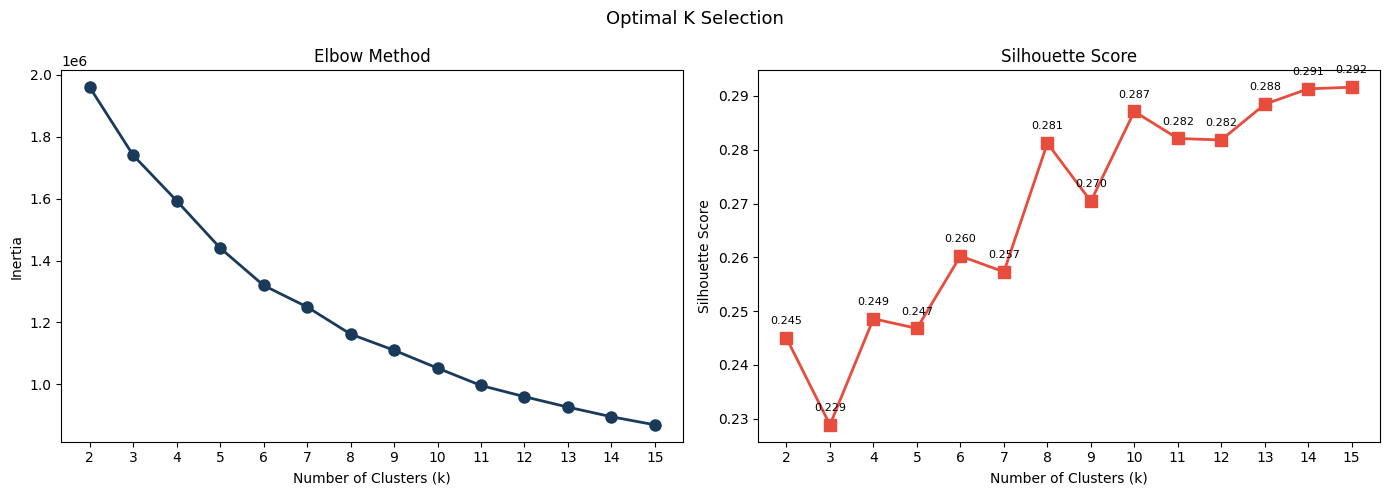


=== K Selection Summary ===
k= 2: Inertia=   1,960,004 | Silhouette=0.2450 | Improvement=0.00%
k= 3: Inertia=   1,740,376 | Silhouette=0.2289 | Improvement=11.21%
k= 4: Inertia=   1,593,318 | Silhouette=0.2486 | Improvement=8.45%
k= 5: Inertia=   1,440,809 | Silhouette=0.2468 | Improvement=9.57%
k= 6: Inertia=   1,319,827 | Silhouette=0.2602 | Improvement=8.40%
k= 7: Inertia=   1,250,300 | Silhouette=0.2573 | Improvement=5.27%
k= 8: Inertia=   1,162,591 | Silhouette=0.2812 | Improvement=7.02%
k= 9: Inertia=   1,110,379 | Silhouette=0.2704 | Improvement=4.49%
k=10: Inertia=   1,052,699 | Silhouette=0.2871 | Improvement=5.19%
k=11: Inertia=     996,556 | Silhouette=0.2821 | Improvement=5.33%
k=12: Inertia=     960,392 | Silhouette=0.2818 | Improvement=3.63%
k=13: Inertia=     926,613 | Silhouette=0.2885 | Improvement=3.52%
k=14: Inertia=     895,537 | Silhouette=0.2913 | Improvement=3.35%
k=15: Inertia=     869,419 | Silhouette=0.2916 | Improvement=2.92%


In [41]:
# Fix plot and extend k range
inertias = []
silhouette_scores = []
k_range = range(2, 16)  # extend to 15

for k in k_range:
    print(f"Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_list = list(k_range)

# Elbow curve
axes[0].plot(k_list, inertias, 'o-', color='#1a3a5c', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_list)

# Silhouette scores
axes[1].plot(k_list, silhouette_scores, 's-', color='#e74c3c', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_list)

# Add value labels on silhouette
for k, s in zip(k_list, silhouette_scores):
    axes[1].annotate(f'{s:.3f}', (k, s),
                     textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=8)

plt.suptitle('Optimal K Selection', fontsize=13)
plt.tight_layout()
plt.show()

# Print summary
print("\n=== K Selection Summary ===")
for k, inertia, sil in zip(k_list, inertias, silhouette_scores):
    pct_improvement = ((inertias[k_list.index(k)-1] - inertia) / inertias[k_list.index(k)-1] * 100) if k > 2 else 0
    print(f"k={k:2d}: Inertia={inertia:>12,.0f} | Silhouette={sil:.4f} | Improvement={pct_improvement:.2f}%")

In [42]:
# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 's-', color='#6fa8dc', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

# Add value labels
for i, (k, s) in enumerate(zip(k_range, silhouette_scores)):
    axes[1].annotate(f'{s:.3f}', (k, s),
                     textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=8)

plt.suptitle('Optimal K Selection', fontsize=13)
plt.tight_layout()
plt.show()

# Print summary
print("\n=== K Selection Summary ===")
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: Inertia={inertia:,.0f} | Silhouette={sil:.4f}")

<Figure size 640x480 with 0 Axes>


=== K Selection Summary ===
k=2: Inertia=1,960,004 | Silhouette=0.2450
k=3: Inertia=1,740,376 | Silhouette=0.2289
k=4: Inertia=1,593,318 | Silhouette=0.2486
k=5: Inertia=1,440,809 | Silhouette=0.2468
k=6: Inertia=1,319,827 | Silhouette=0.2602
k=7: Inertia=1,250,300 | Silhouette=0.2573
k=8: Inertia=1,162,591 | Silhouette=0.2812
k=9: Inertia=1,110,379 | Silhouette=0.2704
k=10: Inertia=1,052,699 | Silhouette=0.2871
k=11: Inertia=996,556 | Silhouette=0.2821
k=12: Inertia=960,392 | Silhouette=0.2818
k=13: Inertia=926,613 | Silhouette=0.2885
k=14: Inertia=895,537 | Silhouette=0.2913
k=15: Inertia=869,419 | Silhouette=0.2916


Both the elbow method and silhouette score were used to determine the optimal number of clusters. The elbow curve showed no sharp bend, with the most significant inertia drops occurring before k=5. While silhouette scores continued to improve slightly beyond k=5, the gains were marginal. k=5 was selected as it balances statistical performance with business interpretability — five distinct segments are actionable for a retail marketing team without being overly complex.

In [80]:
# Load label directly from the saved CSV
df_labels = pd.read_csv('df_with_predictions.csv')[['label']]

# Add label back
df_seg['label'] = df_labels['label'].values

print("Label distribution:")
print(df_seg['label'].value_counts())

# ── 8. TRAIN FINAL K-MEANS WITH K=5 ──────────────────────────────────────────
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_seg['cluster'] = kmeans_final.fit_predict(X_scaled)


Label distribution:
label
0    183785
1     12382
Name: count, dtype: int64


In [81]:
print("\nCluster distribution:")
print(df_seg['cluster'].value_counts().sort_index())

print("\nCluster summary:")
cluster_summary = df_seg.groupby('cluster').agg(
    total=('label', 'count'),
    high_earners=('label', 'sum'),
    pct_high_income=('label', 'mean'),
    avg_income_probability=('income_probability', 'mean'),
    avg_age=('age', 'mean'),
    avg_weeks_worked=('weeks_worked_in_year', 'mean'),
    avg_education_rank=('education_rank', 'mean'),
    avg_investment_income=('total_investment_income', 'mean'),
).round(3)




Cluster distribution:
cluster
0    54874
1    48077
2    37837
3    54934
4      445
Name: count, dtype: int64

Cluster summary:


In [82]:
cluster_summary['pct_high_income'] = (cluster_summary['pct_high_income'] * 100).round(2)
cluster_summary['avg_income_probability'] = (cluster_summary['avg_income_probability'] * 100).round(2)

print(cluster_summary)
cluster_summary['pct_high_income'] = (cluster_summary['pct_high_income'] * 100).round(2)
cluster_summary['avg_income_probability'] = (cluster_summary['avg_income_probability'] * 100).round(2)

print(cluster_summary)

         total  high_earners  pct_high_income  avg_income_probability  \
cluster                                                                 
0        54874           512              0.9                     9.2   
1        48077         10848             22.6                    56.3   
2        37837           623              1.6                     9.4   
3        54934             1              0.0                     0.0   
4          445           398             89.4                    95.1   

         avg_age  avg_weeks_worked  avg_education_rank  avg_investment_income  
cluster                                                                        
0         49.139            21.638               8.801                242.628  
1         42.741            49.361              10.820               1041.165  
2         41.277            27.240               8.886                265.704  
3          9.479             0.224               1.160                  1.496  
4       

In [83]:
print("=== Income Distribution per Cluster ===\n")
for cluster in sorted(df_seg['cluster'].unique()):
    cluster_data = df_seg[df_seg['cluster'] == cluster]
    total = len(cluster_data)
    high_earners = cluster_data['label'].sum()
    pct = (high_earners / total) * 100
    avg_prob = cluster_data['income_probability'].mean() * 100

    print(f"Cluster {cluster}:")
    print(f"  Total people:        {total:,}")
    print(f"  High earners:        {high_earners:,}")
    print(f"  % High income:       {pct:.2f}%")
    print(f"  Avg income prob:     {avg_prob:.2f}%")
    print()

=== Income Distribution per Cluster ===

Cluster 0:
  Total people:        54,874
  High earners:        512
  % High income:       0.93%
  Avg income prob:     9.16%

Cluster 1:
  Total people:        48,077
  High earners:        10,848
  % High income:       22.56%
  Avg income prob:     56.30%

Cluster 2:
  Total people:        37,837
  High earners:        623
  % High income:       1.65%
  Avg income prob:     9.45%

Cluster 3:
  Total people:        54,934
  High earners:        1
  % High income:       0.00%
  Avg income prob:     0.03%

Cluster 4:
  Total people:        445
  High earners:        398
  % High income:       89.44%
  Avg income prob:     95.11%



In [84]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_seg['cluster'] = kmeans_final.fit_predict(X_scaled)

# Then rerun the income distribution code
print("=== Income Distribution per Cluster ===\n")
for cluster in sorted(df_seg['cluster'].unique()):
    cluster_data = df_seg[df_seg['cluster'] == cluster]
    total = len(cluster_data)
    high_earners = cluster_data['label'].sum()
    pct = (high_earners / total) * 100
    avg_prob = cluster_data['income_probability'].mean() * 100

    print(f"Cluster {cluster}:")
    print(f"  Total people:        {total:,}")
    print(f"  High earners:        {high_earners:,}")
    print(f"  % High income:       {pct:.2f}%")
    print(f"  Avg income prob:     {avg_prob:.2f}%")
    print()

=== Income Distribution per Cluster ===

Cluster 0:
  Total people:        54,874
  High earners:        512
  % High income:       0.93%
  Avg income prob:     9.16%

Cluster 1:
  Total people:        48,077
  High earners:        10,848
  % High income:       22.56%
  Avg income prob:     56.30%

Cluster 2:
  Total people:        37,837
  High earners:        623
  % High income:       1.65%
  Avg income prob:     9.45%

Cluster 3:
  Total people:        54,934
  High earners:        1
  % High income:       0.00%
  Avg income prob:     0.03%

Cluster 4:
  Total people:        445
  High earners:        398
  % High income:       89.44%
  Avg income prob:     95.11%



In [85]:
# ── DETAILED CLUSTER PROFILES ─────────────────────────────────────────────────
print("=== DETAILED CLUSTER PROFILES ===\n")

for cluster in sorted(df_seg['cluster'].unique()):
    subset = df_seg[df_seg['cluster'] == cluster]
    total = len(subset)
    pct_high = subset['label'].mean() * 100

    print(f"CLUSTER {cluster} ({total:,} people):")
    print("-" * 50)
    print(f"% earning >$50k:          {pct_high:.1f}%")
    print(f"Avg income probability:   {subset['income_probability'].mean()*100:.1f}%")
    print(f"Avg age:                  {subset['age'].mean():.1f}")
    print(f"Avg weeks worked:         {subset['weeks_worked_in_year'].mean():.1f}")
    print(f"Avg education rank:       {subset['education_rank'].mean():.1f}")
    print(f"Avg investment income:    {subset['total_investment_income'].mean():.1f}")
    print(f"Most common sex:          {subset['sex'].mode()[0]}")
    print(f"Most common marital stat: {subset['marital_stat'].mode()[0]}")
    print(f"Most common occupation:   {subset['major_occupation_code'].mode()[0]}")
    print(f"Most common worker class: {subset['class_of_worker'].mode()[0]}")
    print(f"Most common tax status:   {subset['tax_filer_stat'].mode()[0]}")
    print("=" * 60)
    print()

=== DETAILED CLUSTER PROFILES ===

CLUSTER 0 (54,874 people):
--------------------------------------------------
% earning >$50k:          0.9%
Avg income probability:   9.2%
Avg age:                  49.1
Avg weeks worked:         21.6
Avg education rank:       8.8
Avg investment income:    242.6
Most common sex:          Female
Most common marital stat: Married-civilian spouse present
Most common occupation:   Not in universe
Most common worker class: Not in universe
Most common tax status:   Joint both under 65

CLUSTER 1 (48,077 people):
--------------------------------------------------
% earning >$50k:          22.6%
Avg income probability:   56.3%
Avg age:                  42.7
Avg weeks worked:         49.4
Avg education rank:       10.8
Avg investment income:    1041.2
Most common sex:          Male
Most common marital stat: Married-civilian spouse present
Most common occupation:   Professional specialty
Most common worker class: Private
Most common tax status:   Joint both un

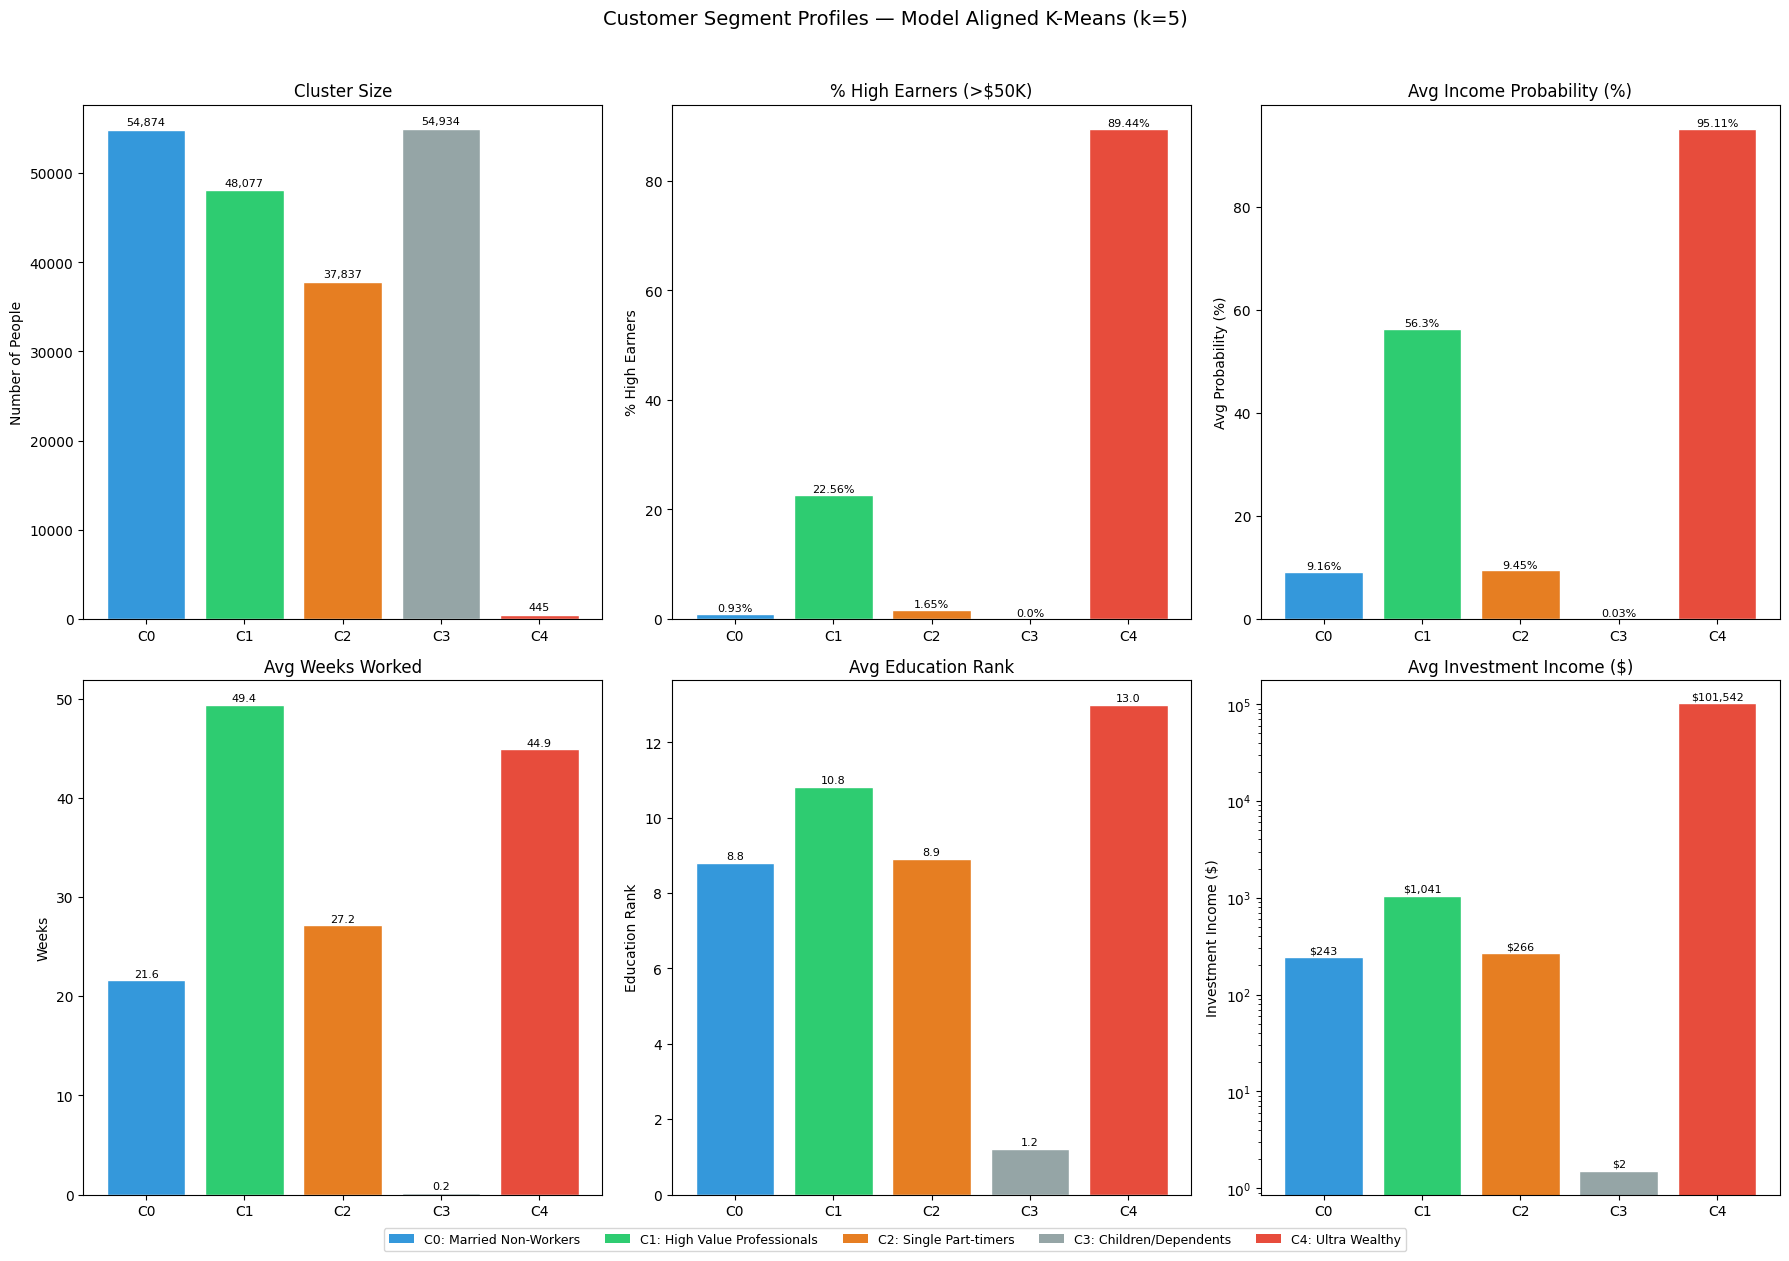

In [86]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

cluster_names = {
    0: 'Married Non-Workers',
    1: 'High Value Professionals',
    2: 'Single Part-timers',
    3: 'Children/Dependents',
    4: 'Ultra Wealthy'
}

colors = ['#3498db', '#2ecc71', '#e67e22', '#95a5a6', '#e74c3c']

# Plot 1: Cluster sizes
sizes = [54874, 48077, 37837, 54934, 445]
axes[0,0].bar([f'C{i}' for i in range(5)], sizes, color=colors, edgecolor='white')
axes[0,0].set_title('Cluster Size', fontsize=12)
axes[0,0].set_ylabel('Number of People')
for i, v in enumerate(sizes):
    axes[0,0].text(i, v + 500, f'{v:,}', ha='center', fontsize=8)

# Plot 2: High earner rate
pct_high = [0.93, 22.56, 1.65, 0.0, 89.44]
axes[0,1].bar([f'C{i}' for i in range(5)], pct_high, color=colors, edgecolor='white')
axes[0,1].set_title('% High Earners (>$50K)', fontsize=12)
axes[0,1].set_ylabel('% High Earners')
for i, v in enumerate(pct_high):
    axes[0,1].text(i, v + 0.5, f'{v}%', ha='center', fontsize=8)

# Plot 3: Avg income probability
avg_prob = [9.16, 56.30, 9.45, 0.03, 95.11]
axes[0,2].bar([f'C{i}' for i in range(5)], avg_prob, color=colors, edgecolor='white')
axes[0,2].set_title('Avg Income Probability (%)', fontsize=12)
axes[0,2].set_ylabel('Avg Probability (%)')
for i, v in enumerate(avg_prob):
    axes[0,2].text(i, v + 0.5, f'{v}%', ha='center', fontsize=8)

# Plot 4: Avg weeks worked
avg_weeks = [21.6, 49.4, 27.2, 0.2, 44.9]
axes[1,0].bar([f'C{i}' for i in range(5)], avg_weeks, color=colors, edgecolor='white')
axes[1,0].set_title('Avg Weeks Worked', fontsize=12)
axes[1,0].set_ylabel('Weeks')
for i, v in enumerate(avg_weeks):
    axes[1,0].text(i, v + 0.3, f'{v}', ha='center', fontsize=8)

# Plot 5: Avg education rank
avg_edu = [8.8, 10.8, 8.9, 1.2, 13.0]
axes[1,1].bar([f'C{i}' for i in range(5)], avg_edu, color=colors, edgecolor='white')
axes[1,1].set_title('Avg Education Rank', fontsize=12)
axes[1,1].set_ylabel('Education Rank')
for i, v in enumerate(avg_edu):
    axes[1,1].text(i, v + 0.1, f'{v}', ha='center', fontsize=8)

# Plot 6: Avg investment income (log scale)
avg_inv = [242.6, 1041.2, 265.7, 1.5, 101542.5]
axes[1,2].bar([f'C{i}' for i in range(5)], avg_inv, color=colors, edgecolor='white')
axes[1,2].set_title('Avg Investment Income ($)', fontsize=12)
axes[1,2].set_ylabel('Investment Income ($)')
axes[1,2].set_yscale('log')
for i, v in enumerate(avg_inv):
    axes[1,2].text(i, v * 1.1, f'${v:,.0f}', ha='center', fontsize=8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=f'C{i}: {cluster_names[i]}')
                   for i in range(5)]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Customer Segment Profiles — Model Aligned K-Means (k=5)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

Variance explained by PC1: 30.0%
Variance explained by PC2: 12.5%
Total variance explained:  42.5%


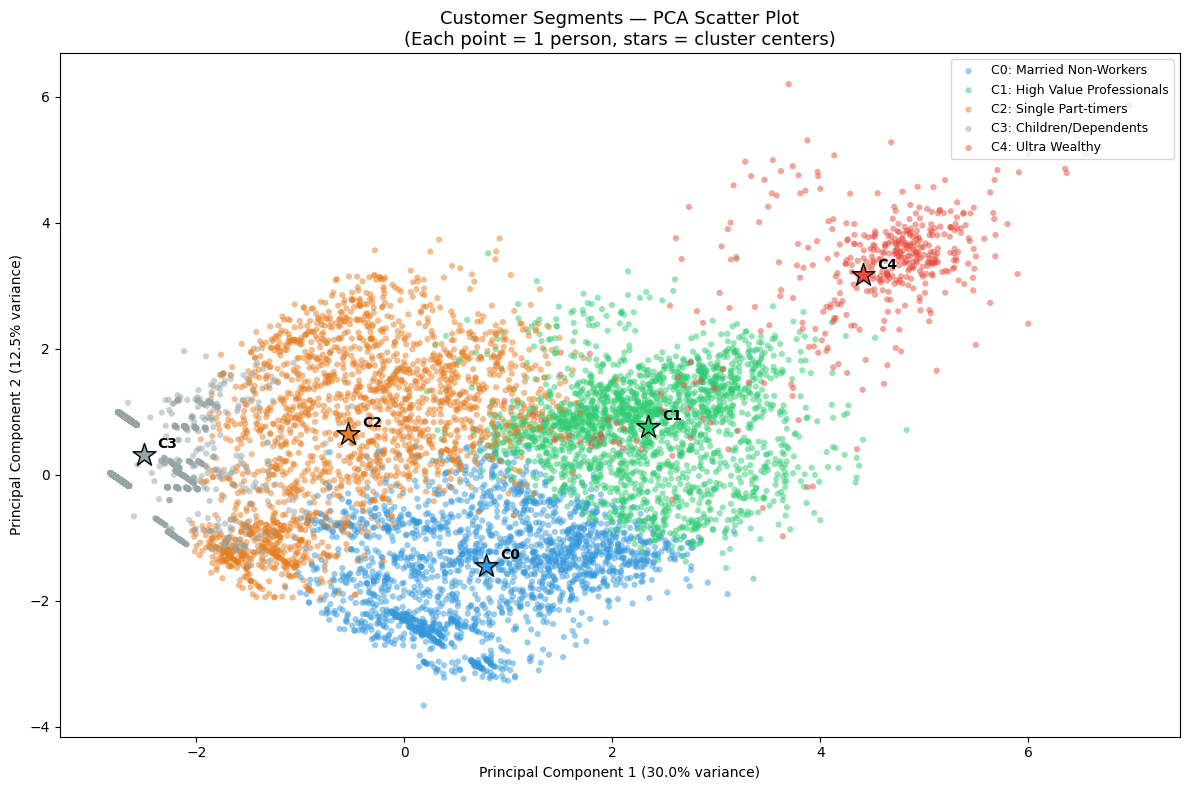

In [87]:
# ── SCATTER PLOT USING PCA ────────────────────────────────────────────────────
from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained:  {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#3498db', '#2ecc71', '#e67e22', '#95a5a6', '#e74c3c']
cluster_names = {
    0: 'Married Non-Workers',
    1: 'High Value Professionals',
    2: 'Single Part-timers',
    3: 'Children/Dependents',
    4: 'Ultra Wealthy'
}

# Plot each cluster
for cluster in sorted(df_seg['cluster'].unique()):
    mask = df_seg['cluster'] == cluster

    # Sample for visibility (plotting 196k points is slow)
    sample_size = min(2000, mask.sum())
    sample_idx = df_seg[mask].sample(sample_size, random_state=42).index

    ax.scatter(
        X_pca[sample_idx, 0],
        X_pca[sample_idx, 1],
        c=colors[cluster],
        label=f'C{cluster}: {cluster_names[cluster]}',
        alpha=0.5,
        s=20,
        edgecolors='none'
    )

# Plot cluster centers
centers_pca = pca.transform(kmeans_final.cluster_centers_)
for i, center in enumerate(centers_pca):
    ax.scatter(center[0], center[1],
               c=colors[i], s=300,
               marker='*',
               edgecolors='black',
               linewidth=1,
               zorder=5)
    ax.annotate(f'C{i}', (center[0], center[1]),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=10,
                fontweight='bold')

ax.set_title('Customer Segments — PCA Scatter Plot\n(Each point = 1 person, stars = cluster centers)',
             fontsize=13)
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()